In [ ]:
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using OrdinaryDiffEq
using Plots

@connector Pin begin
    v(t)
    i(t), [connect = Flow]
end
sigmoid(x) = 1.0 / (1.0 + exp(-x))
@mtkmodel Ground begin
    @parameters begin
        Ev = -70.0
    end
    @components begin
        g = Pin()
    end
    @equations begin
        g.v ~ Ev
    end
end

@mtkmodel OnePort begin
    @components begin
        p = Pin()
        n = Pin()
    end
    @variables begin
        v(t)
        i(t)
    end
    @equations begin
        v ~ p.v - n.v
        0 ~ p.i + n.i
        i ~ p.i
    end
end

"""
I = gleak*(V - Eleak )
"""


@component function LeakChannel(; v_in, name, kwargs...)
    pars = @parameters begin
        gleak = 0.002#0.003
        Eleak = -69.42#-49.42
    end

    vars = @variables begin
        i(t)#, [connect = Flow]
    end
    v = v_in
    eqs = [
        i ~ gleak * (v - Eleak)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end





@component function SodiumChannel(;name, kwargs...)
    αₘ(x) = 0.1(35.0 + x) / (
        -exp(
            -(35.0 + x) / 10.0
        ) + 1.0
    )
    βₘ(x) = 4exp(
        -(x + 60) / 18.0
    )
    αₕ(x) = 0.07exp(-(x + 60.0) / 20.0)
    βₕ(x) = 1.0 / (
        1 + exp(
            (-30.0 - x) / 10.0
        )
    )
    pars = @parameters begin
        gNa = 1.2
        ENa = 55.17
    end
    vars = @variables begin
        m(t)=0
        h(t)=0
        i(t)#, [connect=Flow]
    end
        
    v = kwargs[:v_in]
    eqs = [
        D(m) ~ αₘ(v) * (1 - m) - βₘ(v) * m,
        D(h) ~ αₕ(v) * (1 - h) - βₕ(v) * h,
        i ~ gNa * m^3 * h * (ENa - v)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end



@component function PotassiumChannel(; v_in, name, kwargs...)
    pars = @parameters begin
        gK = 0.36
        EK = -72.14
    end
    vars = @variables begin
        n(t) = 0.0
        i(t)#, [connect=Flow]
    end
    v = v_in
    αₙ(x) = 0.01(x + 50.0) / (1 - exp(
        -(50.0 + x) / 10.0
    )
    )
    βₙ(x) = 0.125exp(-(x + 60) / 80.0)
    τₙ(x) = 1.0 / (αₙ(x) + βₙ(x))
    eqs = [
        D(n) ~ αₙ(v) * (1 - n) - βₙ(v) * n,
        i ~ gK * n^4 * min(EK - v,0)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end


@component function CalciumChannel(; v_in, name, kwargs...)
    pars = @parameters begin
        gCa = 0.1
        ECa = 120.0  # Very positive reversal potential
    end
    
    vars = @variables begin
        s(t) = 0.0  # Activation variable
        i(t)
        ca_conc(t) = 0.0  # Track intracellular calcium
    end
    
    v = v_in
    # Ca2+ activation dynamics
    αₛ(x) = 0.055(-27.0 - x)/(exp((-27.0 - x)/3.8) - 1)
    βₛ(x) = 0.94*exp((-75.0 - x)/17.0)
    
    # Ca2+ concentration dynamics (simplified)
    eqs = [
        D(s) ~ αₛ(v) * (1 - s) - βₛ(v) * s,
        i ~ gCa * s^2 * (ECa - v),
        D(ca_conc) ~ -0.13 * i - 0.075 * ca_conc  # Simple decay model
    ]
    
    return ODESystem(eqs, t, vars, pars; name)
end

@mtkmodel ActivationGate begin
    @extend OnePort()
    @variables Sodium(t)
end

"""
@component function Synapse(;name, presynaptic, kwargs...)
    pars = @parameters begin
        gap_C = 100
        time_delay = 1.0
        pulse_width = 0.5
    end

    vars = @variables begin
        last_spike(t) = -100.0
        # Remove i(t) declaration completely
    end

    # No return value for current - we'll calculate it in Network
    eqs= [
        D(last_spike) ~ ifelse((presynaptic > 0) * (last_spike - (t - 5.0) < 0), 
                      t - last_spike, 0.0)
        # Remove the i equation completely
    ]
    return ODESystem(eqs, t, vars, pars; name)
end
"""

@component function ChemSynapse(;name, presynaptic_v, kwargs...)
    pars 

@component function FullESynapse(;name, presynaptic_v, kwargs...)
    pars = @parameters begin
        myelination = 0.8
        distance = 20
        signal_amplitude


@component function ESynapse(;name, presynaptic_v, kwargs...)
    pars = @parameters begin
        g_syn = 0.02
        v_threshold = -40.0
        E_syn = 0.0
        tau_rise = 0.5
        tau_decay = 2.0
        conductance = 1.0
    end

    vars = @variables begin
        s(t) = 0.0  # Synaptic gating variable
        i(t)        # Synaptic current
    end

    # Get presynaptic voltage
    v_pre = presynaptic_v
    
    # Sigmoid activation function for smooth transition
    
    activation(v) = 1 / (1 + exp(-(v - v_threshold) / 2))
    eqs = [
        # Differential equation for synaptic gating variable
        # Increases when presynaptic neuron is depolarized, otherwise decays
        D(s) ~ activation(v_pre) * (1 - s) / tau_rise - s / tau_decay,
        
        # Synaptic current
        i ~ g_syn * s * (E_syn - kwargs[:postsynaptic_v])
    ]
    
    return ODESystem(eqs, t, vars, pars; name)
end

@component function ISynapse(;name, presynaptic_v, kwargs...)
    pars = @parameters begin
        g_syn = 0.1  # Stronger conductance for inhibition
        v_threshold = -40.0
        E_syn = -80.0  # Inhibitory reversal potential (more negative than resting)
        tau_rise = 0.5
        tau_decay = 5.0  # Slower decay for inhibition
    end

    vars = @variables begin
        s(t) = 0.0
        i(t)
    end

    v_pre = presynaptic_v
    activation(v) = 1 / (1 + exp(-(v - v_threshold) / 2))
    
    eqs = [
        D(s) ~ activation(v_pre) * (1 - s) / tau_rise - s / tau_decay,
        i ~ g_syn * s * (E_syn - kwargs[:postsynaptic_v])
    ]
    
    return ODESystem(eqs, t, vars, pars; name)
end

@component function HHNeuron(;name, input_current=0.0, kwargs...)
    pars = @parameters begin
        C = 0.01
        gap_C = 0.02
        spike_threshold=-40.0
    end

    vars = @variables begin
        v(t) = -70
        i(t)#, [connect=Flow]
    end
    systems = @named begin
        so = SodiumChannel(; v_in = v)
        po = PotassiumChannel(; v_in = v)
        #ca = CalciumChannel(; v_in = v)
        l = LeakChannel(; v_in = v)
    end
    
    # Sum the currents from ion channels first
    channel_currents = sum(el.i for el in systems)
    # Then add the input current
    eqs = [
        C * D(v) ~ so.i+po.i+l.i + input_current   
    ]
    return ODESystem(eqs, t, vars, pars; systems, name)
end

@component function InhibitoryHHNeuron(;name, input_current=0.0)
    pars = @parameters begin
        C = 0.01  # Membrane capacitance
        τ_decay = 10.0  # Slower decay - sustains inhibition
        g_leak = 0.005  # Higher leak conductance
        E_leak = -65.0  # Resting potential
        spike_threshold = -45.0  # Lower threshold for easier activation
        v_reset = -75.0  # Hyperpolarized reset
        g_max = 0.3  # Strong inhibitory output
    end

    vars = @variables begin
        v(t) = -65.0  # Membrane potential
        i_output(t) = 0.0  # Inhibitory output current
    end
    
    # Add channels with modified parameters for faster activation
    systems = @named begin
        so = SodiumChannel(v_in=v, gNa=1.5)  # Stronger sodium current
        po = PotassiumChannel(v_in=v, gK=0.3)  # Weaker potassium current
        l = LeakChannel(v_in=v, gleak=g_leak, Eleak=E_leak)
    end
    
    eqs = [
        # Membrane potential dynamics
        C * D(v) ~ so.i + po.i + l.i + input_current,
        
        # Output inhibitory current proportional to membrane potential
        i_output ~ g_max * sigmoid((v + 55.0)/5.0) * (E_leak - v)
    ]
    
    return ODESystem(eqs, t, vars, pars; systems, name)
end

@component function LIFNeuron(;name, input_current=0.0, kwargs...)
    pars = @parameters begin
        τ_m = 10.0     # Membrane time constant (ms)
        v_rest = -70.0  # Resting potential (mV)
        v_thresh = -55.0 # Threshold potential (mV)
        v_reset = -75.0  # Reset potential (mV)
        R = 1.0         # Membrane resistance (arbitrary units)
    end

    vars = @variables begin
        v(t) = v_rest  # Membrane potential
        i(t)           # Output current
        spike(t) = 0.0 # Spike indicator
    end
    
    eqs = [
        # LIF dynamics: tau * dv/dt = -(v - v_rest) + R*I
        τ_m * D(v) ~ -(v - v_rest) + R * input_current,
        
        # Reset mechanism with spike detection
        v ~ ifelse(v > v_thresh, v_reset, v),
        
        # Spike detection for connections
        spike ~ ifelse(v > v_thresh, 1.0, 0.0),
        
        # Output current (can be used to connect to other neurons)
        i ~ ifelse(spike > 0.5, 1.0, 0.0) * 0.5
    ]
    
    return ODESystem(eqs, t, vars, pars; name)
end

@component function Network(;name)
    pars = @parameters begin
        gap_C = 0.02
    end
    # Explicitly define all variables
    vars = @variables begin
        synaptic_current_1(t)
        synaptic_current_2(t)
        synaptic_current_3(t)
        isynaptic_current_1(t)
        isynaptic_current_2(t)
    end
    @named lif_neuron = LIFNeuron(name=:lif_neuron, input_current=5.0)
    @named lif_synapse_1 = ESynapse(name=:lif_synapse_1, presynaptic_v=lif_neuron.v, postsynaptic_v=neuron_pre_1)
    @named lif_synapse_2 = ESynapse(name=:lif_synapse_2, presynaptic_v=lif_neuron.v, postsynaptic_v=neuron_pre_2)
    @named lif_synapse_3 = ESynapse(name=:lif_synapse_3, presynaptic_v=lif_neuron.v, postsynaptic_v=neuron_pre_3)

    @named neuron_post_1 = HHNeuron(name=:neuron_post_1, input_current=synaptic_current_1+isynaptic_current_1)
    @named neuron_post_2 = HHNeuron(name=:neuron_post_2, input_current=synaptic_current_2+isynaptic_current_2)
    @named neuron_inhibiter = InhibitoryHHNeuron(name=:neuron_inhibiter, input_current=synaptic_current_3)

    @named neuron_pre_1 = HHNeuron(name=:neuron_pre_1, input_current=1.5)
    @named neuron_pre_2 = HHNeuron(name=:neuron_pre_2, input_current=1.0)
    @named neuron_pre_3 = HHNeuron(name=:neuron_pre_3, input_current=2.0)

    @named synapse_1 = ESynapse(name=:synapse_1, presynaptic_v=neuron_pre_1.v, postsynaptic_v=neuron_post_1.v)
    @named synapse_2 = ESynapse(name=:synapse_2, presynaptic_v=neuron_pre_2.v, postsynaptic_v=neuron_post_1.v)
    @named synapse_3 = ESynapse(name=:synapse_3, presynaptic_v=neuron_pre_3.v, postsynaptic_v=neuron_post_2.v)
    @named synapse_4 = ESynapse(name=:synapse_4, presynaptic_v=neuron_post_1.v, postsynaptic_v=neuron_inhibiter.v)
    @named synapse_5 = ESynapse(name=:synapse_5, presynaptic_v=neuron_post_2.v, postsynaptic_v=neuron_inhibiter.v)

    @named isynapse_1 = ISynapse(name=:isynapse_1, presynaptic_v=neuron_inhibiter.v, postsynaptic_v=neuron_post_1.v)
    @named isynapse_2 = ISynapse(name=:isynapse_2, presynaptic_v=neuron_inhibiter.v, postsynaptic_v=neuron_post_2.v)

    systems = [neuron_pre_1, neuron_pre_2, neuron_pre_3, neuron_post_1, neuron_post_2, neuron_inhibiter, synapse_1, synapse_2, synapse_3, synapse_4, synapse_5, isynapse_1, isynapse_2]

    eqs = [
        synaptic_current_1 ~ synapse_1.i + synapse_2.i
        synaptic_current_2 ~ synapse_3.i
        synaptic_current_3 ~ synapse_4.i + synapse_5.i
        isynaptic_current_1 ~ isynapse_1.i
        isynaptic_current_2 ~ isynapse_2.i
    ]

    return ODESystem(eqs, t, vars, pars; systems, name)
end

coupled = Network(name=:coupled)
coupled = structural_simplify(coupled)
coupled.synaptic_current_1 => 0.0
coupled.synaptic_current_2 => 0.0
coupled.synaptic_current_3 => 0.0
coupled.isynaptic_current_1 => 0.0
coupled.isynaptic_current_2 => 0.0

prob = ODEProblem(coupled, [], (0.0, 20))
sol = solve(prob, Tsit5())

┌ Warning: Initialization system is overdetermined. 1 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit C:\Users\eloya\.julia\packages\ModelingToolkit\YLJ0I\src\systems\diffeqs\abstractodesystem.jl:1277


retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 115-element Vector{Float64}:
  0.0
  0.006020295824754712
  0.026305477084572027
  0.060105212268337996
  0.09528583338180062
  0.12309630189870535
  0.1506906653709809
  0.1796955145643305
  0.21723286309356132
  0.25530865501356875
  ⋮
 19.18187931773871
 19.28020441817822
 19.380543180994263
 19.481703319430697
 19.58239358270837
 19.678556786123536
 19.786070513182516
 19.901706290579895
 20.0
u: 115-element Vector{Vector{Float64}}:
 [-70.0, 0.0, 0.0, 0.0, -70.0, 0.0, 0.0, 0.0, -70.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [-69.09711052350531, 0.0006649733282753106, 0.0006790884082515212, 0.00019403417813526895, -69.39830660730722, 0.0006573128253504347, 0.0006841869727158159, 0.00019211991673341846, -68.79591443970338, 0.0006727377186714127  …  0.0009311721901802209, 0.0005408488084559204, 0.0002592749781411698, 4.648555352412575e-9, 4.291026539142829e-9, 5.045301140376754e-9, 3.67706

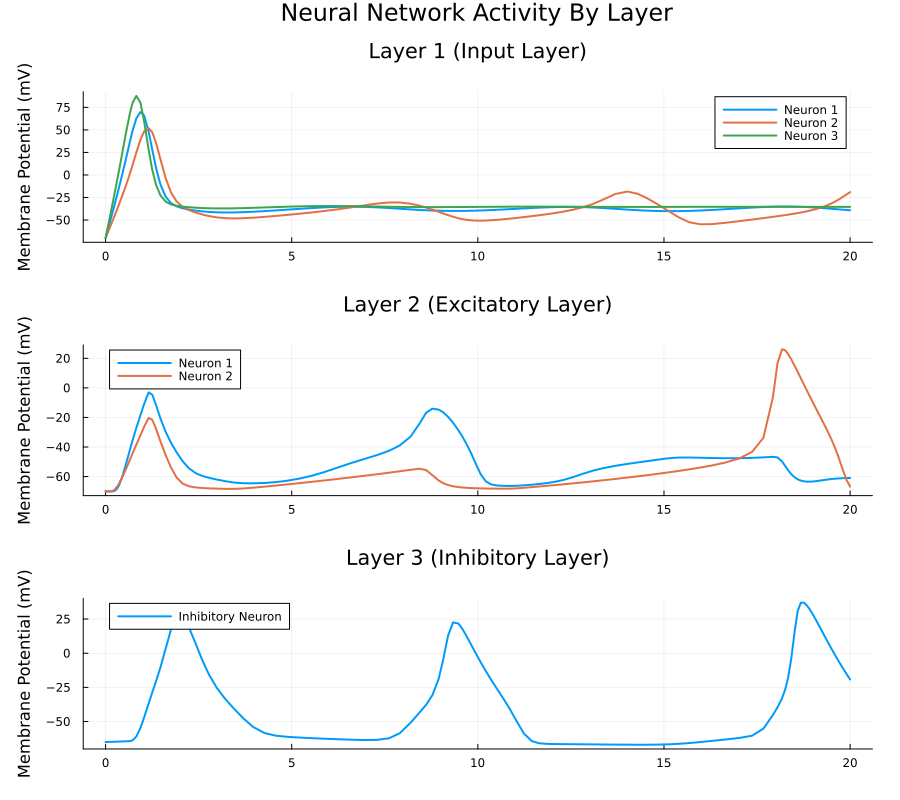

In [24]:
pre1_v = [sol[coupled.neuron_pre_1.v][i] for i in 1:length(sol.t)]
pre2_v = [sol[coupled.neuron_pre_2.v][i] for i in 1:length(sol.t)]
pre3_v = [sol[coupled.neuron_pre_3.v][i] for i in 1:length(sol.t)]
post1_v = [sol[coupled.neuron_post_1.v][i] for i in 1:length(sol.t)]
post2_v = [sol[coupled.neuron_post_2.v][i] for i in 1:length(sol.t)]
inhib_v = [sol[coupled.neuron_inhibiter.v][i] for i in 1:length(sol.t)]

# Create subplots for each layer
layer1 = plot(sol.t, [pre1_v pre2_v pre3_v], 
     label=["Neuron 1" "Neuron 2" "Neuron 3"],
     title="Layer 1 (Input Layer)",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

layer2 = plot(sol.t, [post1_v post2_v], 
     label=["Neuron 1" "Neuron 2"],
     title="Layer 2 (Excitatory Layer)",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

layer3 = plot(sol.t, inhib_v,
     label="Inhibitory Neuron",
     title="Layer 3 (Inhibitory Layer)",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

# Combine into vertical layout to show signal propagation through layers
plot(layer1, layer2, layer3, 
     layout=(3,1), 
     size=(900, 800),
     plot_title="Neural Network Activity By Layer",
     margin=5Plots.mm)

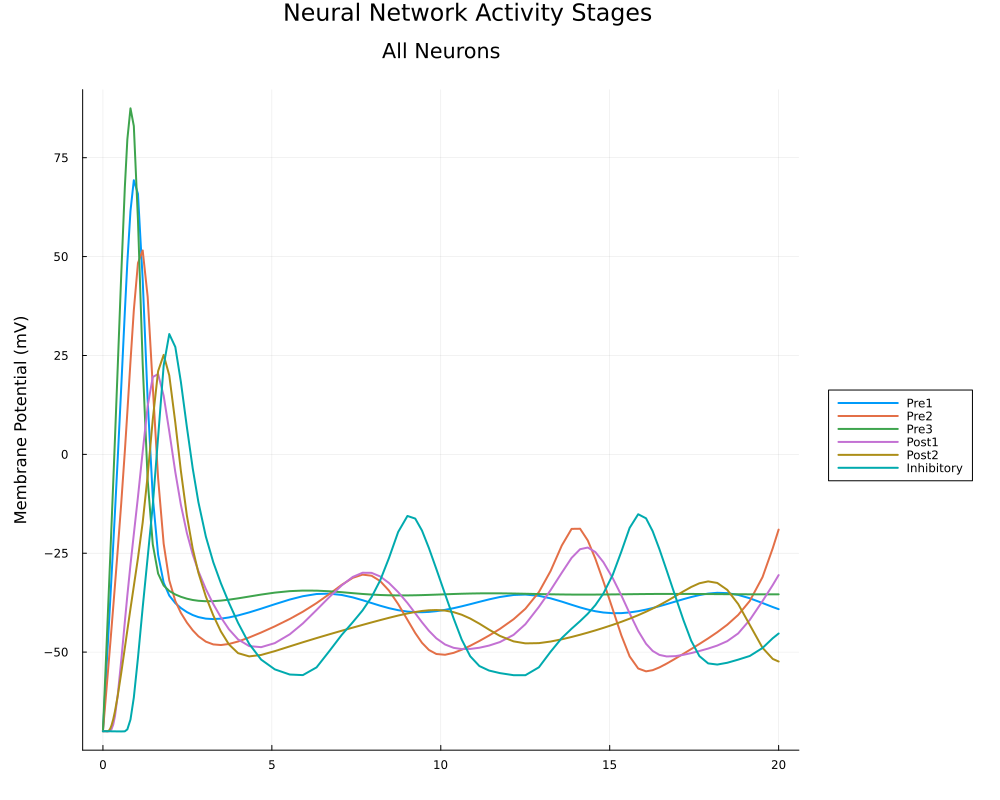

In [19]:
pre1_v = [sol[coupled.neuron_pre_1.v][i] for i in 1:length(sol.t)]
pre2_v = [sol[coupled.neuron_pre_2.v][i] for i in 1:length(sol.t)]
pre3_v = [sol[coupled.neuron_pre_3.v][i] for i in 1:length(sol.t)]
post1_v = [sol[coupled.neuron_post_1.v][i] for i in 1:length(sol.t)]
post2_v = [sol[coupled.neuron_post_2.v][i] for i in 1:length(sol.t)]
inhib_v = [sol[coupled.neuron_inhibiter.v][i] for i in 1:length(sol.t)]

# Create plots
p1 = plot(sol.t, [pre1_v pre2_v pre3_v], 
     label=["Pre1" "Pre2" "Pre3"],
     title="Pre-synaptic Neurons",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

p2 = plot(sol.t, [post1_v post2_v], 
     label=["Post1" "Post2"],
     title="Post-synaptic Neurons",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

p3 = plot(sol.t, inhib_v,
     label="Inhibitory Neuron",
     title="Inhibitory Neuron",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

p4 = plot(sol.t, [pre1_v pre2_v pre3_v post1_v post2_v inhib_v], 
     label=["Pre1" "Pre2" "Pre3" "Post1" "Post2" "Inhibitory"],
     title="All Neurons",
     ylabel="Membrane Potential (mV)",
     linewidth=2)

# Arrange in a layout
plot(p4, size=(1000, 800), 
     legend=:outerright, 
     plot_title="Neural Network Activity Stages",
     margin=5Plots.mm)

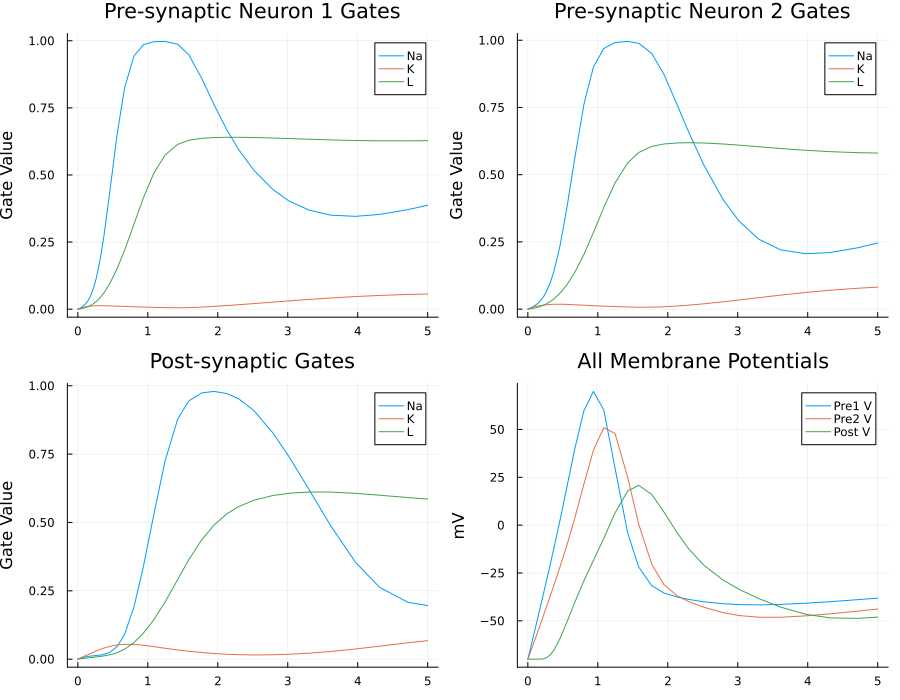

In [13]:
# Extract data
pre1_v = [state[1] for state in sol.u]
pre1_Na = [state[2] for state in sol.u]
pre1_K = [state[3] for state in sol.u]
pre1_L = [state[4] for state in sol.u]

pre2_v = [state[5] for state in sol.u]
pre2_Na = [state[6] for state in sol.u]
pre2_K = [state[7] for state in sol.u]
pre2_L = [state[8] for state in sol.u]

post_v = [state[9] for state in sol.u]
post_Na = [state[10] for state in sol.u]
post_K = [state[11] for state in sol.u]
post_L = [state[12] for state in sol.u]

# Four plots layout
p1 = plot(sol.t, [pre1_Na pre1_K pre1_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Neuron 1 Gates",
     ylabel="Gate Value")

p2 = plot(sol.t, [pre2_Na pre2_K pre2_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Neuron 2 Gates",
     ylabel="Gate Value")

p3 = plot(sol.t, [post_Na post_K post_L],
     label=["Na" "K" "L"],
     title="Post-synaptic Gates",
     ylabel="Gate Value")

p4 = plot(sol.t, [pre1_v pre2_v post_v],
     label=["Pre1 V" "Pre2 V" "Post V"],
     title="All Membrane Potentials",
     ylabel="mV")

# Arrange in a 2×2 grid
plot(p1, p2, p3, p4, layout=(2,2), size=(900, 700))

In [36]:
# Extract synapse data
syn1_last_spike = [state[13] for state in sol.u]
syn1_current = [state[14] for state in sol.u]  # Synaptic current
syn1_spike_occurred = diff([0; syn1_last_spike]) .> 0.1  # Detect changes in last_spike

syn2_last_spike = [state[15] for state in sol.u]
syn2_current = [state[16] for state in sol.u]
syn2_spike_occurred = diff([0; syn2_last_spike]) .> 0.1

# Create synapse plots
p_syn1 = plot(sol.t, syn1_current,
    label="Syn1 Current",
    title="Synapse 1 Activity",
    ylabel="Current")

p_syn2 = plot(sol.t, syn2_current,
    label="Syn2 Current", 
    title="Synapse 2 Activity",
    ylabel="Current")

# Add spike markers
for t_idx in findall(syn1_spike_occurred)
   vline!(p_syn1, [sol.t[t_idx]], label="", color=:red, alpha=0.5)
end

for t_idx in findall(syn2_spike_occurred)
   vline!(p_syn2, [sol.t[t_idx]], label="", color=:red, alpha=0.5)
end

# Plot both synapses
plot(p_syn1, p_syn2, layout=(2,1), size=(800, 400))

BoundsError: BoundsError: attempt to access 14-element Vector{Float64} at index [15]

In [ ]:
pre_v = [state[1] for state in sol.u]
pre_Na = [state[2] for state in sol.u]
pre_K = [state[3] for state in sol.u]
pre_L = [state[4] for state in sol.u]

# Post-synaptic neuron
post_v = [state[5] for state in sol.u]
post_Na = [state[6] for state in sol.u]
post_K = [state[7] for state in sol.u]
post_L = [state[8] for state in sol.u]

# Create a 2x2 subplot layout
p1 = plot(sol.t, [pre_Na pre_K pre_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Gates",
     ylabel="Gate Value")

p2 = plot(sol.t, [post_Na post_K post_L],
     label=["Na" "K" "L"],
     title="Post-synaptic Gates",
     ylabel="Gate Value")

p3 = plot(sol.t, pre_v,
     label="Pre V",
     title="Membrane Potentials",
     ylabel="mV")

p4 = plot(sol.t, post_v,
     label="Post V",
     title="",
     ylabel="mV")

plot(p1, p2, p3, p4, layout=(2,2))

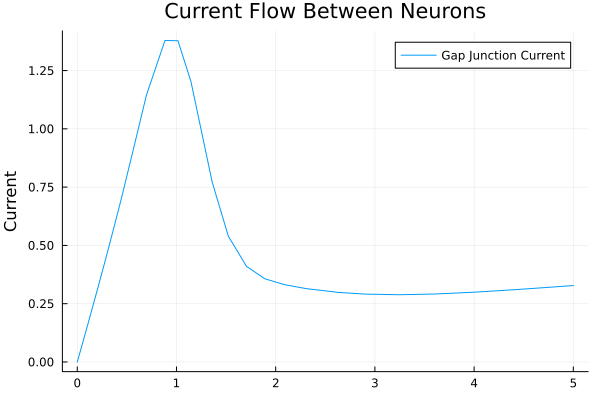

In [22]:
gap_current = [0.01 * (state[1] - state[5]) for state in sol.u]  # Using gap_C = 0.01
plot(sol.t, gap_current,
     label="Gap Junction Current",
     title="Current Flow Between Neurons",
     ylabel="Current")